# Evaluación Parcial N°1 — TLY1102
## Clasificación de letras del alfabeto dactilológico (ASL) mediante un Perceptrón Multicapa

**Asignatura:** Técnicas Avanzadas de Machine Learning I (TLY1102)
**Evaluación:** EP1 — Presentación y defensa técnica del proyecto (30%)
**Entrega:** Informe técnico (.md) · Notebook (.ipynb) · Dataset y archivos complementarios · Carpeta de proyecto

> **Reproducibilidad.** Este notebook es completamente ejecutable de principio a fin.
> Requiere los archivos `data/sign_mnist_train.csv` y `data/sign_mnist_test.csv`,
> que vienen incluidos en la carpeta del proyecto. Todas las operaciones aleatorias
> usan la semilla `SEED = 42`, por lo que los resultados son reproducibles.

## a. Introducción

### El problema

Las personas sordas que usan el alfabeto dactilológico (*fingerspelling*) se comunican
deletrando palabras con la mano. Un sistema capaz de **reconocer automáticamente la letra
que forma una mano en una imagen** permite construir herramientas de accesibilidad:
subtitulado en vivo de una conversación, traducción de señas a texto, o aplicaciones
educativas para aprender el alfabeto.

Formulamos el problema como una tarea de **clasificación supervisada de imágenes**:

> Dada una imagen en escala de grises de 28×28 píxeles que contiene la mano de una persona
> formando una seña del alfabeto ASL, predecir a qué letra corresponde.

### La variante del proyecto

El enunciado exige definir una variante propia para evitar copias entre grupos. Nuestra
variante tiene **tres decisiones**:

1. **Subconjunto de 11 letras: A, B, C, D, E, F, G, H, I, K, L** (las letras de A a L
   excluyendo la J). El dataset omite J y Z porque en ASL requieren movimiento, no una
   postura estática. Trabajar con 11 clases en lugar de 24 nos permite estudiar el
   problema en condiciones controladas y luego **medir el costo de ampliar el número
   de clases**.

2. **Comparación de dos arquitecturas MLP** con distinto número de capas ocultas
   (1 capa de 128 neuronas vs 2 capas de 256 y 128 neuronas). Esto convierte el trabajo
   en una **experimentación básica** y no en un simple "ejecutar el modelo": podemos
   afirmar algo respaldado con datos sobre el efecto de la profundidad.

3. **Experimento de robustez a la traslación**, que cuantifica empíricamente la
   limitación central de un MLP frente a imágenes (limitación que la pauta pide discutir
   explícitamente).

### Objetivo

Construir y evaluar un Perceptrón Multicapa que clasifique las 11 letras del subconjunto,
reportando métricas de desempeño, analizando los errores y las limitaciones del enfoque,
aplicando las etapas del proceso CRISP-DM.

### ¿Por qué este dataset?

Elegimos el **Sign Language MNIST** porque, a diferencia de los otros sets propuestos, sus
imágenes ya están normalizadas a un formato fijo y limpio (28×28 px, escala de grises), lo
que **aísla la variable que queremos estudiar**: el comportamiento de un MLP. Con imágenes
RGB de alta resolución (como en Oxford-IIIT Pet o Intel Image), el resultado estaría dominado
por el preprocesamiento de imágenes y no por la arquitectura de la red. Además, el ejemplo
de "un subconjunto de letras del lenguaje de señas" está mencionado explícitamente en el
enunciado, y las clases están balanceadas, lo que evita que las métricas se distorsionen por
desbalanceo.

## 0. Configuración del entorno

In [1]:
# Librerías base
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modelado
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# Semilla única para TODA la experimentación: garantiza reproducibilidad
SEED = 42
np.random.seed(SEED)
print("Librerías cargadas. Semilla:", SEED)

Librerías cargadas. Semilla: 42


### Localización de los datos (funciona en local y en Google Colab)

Esta celda busca el archivo `sign_mnist_train.csv` en las ubicaciones habituales. Si estás en
Colab y no lo encuentra, te pedirá que subas los dos CSV en ese momento.

In [2]:
# ---------------------------------------------------------------- datos
def buscar_datos():
    """Busca la carpeta que contiene sign_mnist_train.csv en las ubicaciones habituales."""
    candidatas = [
        os.path.join(os.getcwd(), "data"),            # notebook abierto desde la raíz del proyecto
        os.path.join(os.getcwd(), "..", "data"),      # notebook abierto desde notebooks/
        os.path.join(os.getcwd(), "..", "..", "data"),
        "/content/data",                              # Google Colab (carpeta data)
        "/content",                                   # Google Colab (CSV sueltos)
    ]
    for d in candidatas:
        if os.path.exists(os.path.join(d, "sign_mnist_train.csv")):
            return os.path.abspath(d)
    return None

IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
DATA = buscar_datos()

if DATA is None and IN_COLAB:
    # En Colab no hay carpeta del proyecto: hay que subir los dos CSV una sola vez.
    print("No se encontraron los datos.")
    print("Sube los DOS archivos: sign_mnist_train.csv y sign_mnist_test.csv")
    from google.colab import files
    subidos = files.upload()
    os.makedirs("/content/data", exist_ok=True)
    for nombre, contenido in subidos.items():
        with open(os.path.join("/content/data", nombre), "wb") as f:
            f.write(contenido)
    DATA = buscar_datos()

if DATA is None:
    raise FileNotFoundError(
        "No se encontró 'sign_mnist_train.csv'.\n\n"
        "EN LOCAL: abre el notebook desde la carpeta del proyecto (la que contiene data/).\n\n"
        "EN GOOGLE COLAB, tienes dos opciones:\n"
        "  a) Volver a ejecutar esta celda y subir los dos CSV cuando te los pida.\n"
        "  b) Montar Drive y copiarlos:\n"
        "       from google.colab import drive; drive.mount('/content/drive')\n"
        "       !mkdir -p /content/data && cp <ruta_en_drive>/data/*.csv /content/data/\n"
    )

print("Carpeta de datos:", DATA)
print("Archivos encontrados:", [f for f in sorted(os.listdir(DATA)) if f.endswith('.csv')])

Carpeta de datos: C:\Users\demis\proyecto_tly1102\data
Archivos encontrados: ['sign_mnist_test.csv', 'sign_mnist_train.csv']


In [3]:
# ------------------------------------------------------- rutas de salida
# Si el proyecto tiene las carpetas images/ y models/ se usan tal cual (ejecución local).
# Si no existen (por ejemplo en Colab, donde solo hay el notebook), se crean junto al notebook.
RAIZ = os.path.dirname(DATA)

def carpeta_salida(nombre):
    ruta_proyecto = os.path.join(RAIZ, nombre)
    if os.path.isdir(ruta_proyecto):
        return ruta_proyecto
    ruta_local = os.path.join(os.getcwd(), nombre)
    os.makedirs(ruta_local, exist_ok=True)
    return ruta_local

IMG = carpeta_salida("images")
MODELS = carpeta_salida("models")

print("Figuras ->", IMG)
print("Modelos ->", MODELS)

# Mapas de conversión entre índice y letra
LETRA   = {i: chr(65 + i) for i in range(26)}        # 0->A, 1->B, ... 25->Z
PRESENT = sorted(set(range(26)) - {9, 25})            # el dataset omite J(9) y Z(25)
CLASES_VAR = [c for c in PRESENT if c <= 11]          # A..L sin J  ->  11 clases

print("Clases del subconjunto:", [LETRA[c] for c in CLASES_VAR])

Figuras -> C:\Users\demis\proyecto_tly1102\images
Modelos -> C:\Users\demis\proyecto_tly1102\models
Clases del subconjunto: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L']


## b. Comprensión y exploración del conjunto de datos (EDA)

Comenzamos cargando el dataset y respondiendo las preguntas básicas de calidad de datos:
¿cuántas imágenes hay?, ¿cuántas clases?, ¿están balanceadas?, ¿hay valores nulos?,
¿qué rango tienen los píxeles?

In [4]:
train_df = pd.read_csv(os.path.join(DATA, "sign_mnist_train.csv"))
test_df  = pd.read_csv(os.path.join(DATA, "sign_mnist_test.csv"))

print("Forma de entrenamiento:", train_df.shape)
print("Forma de prueba      :", test_df.shape)
print("Columnas             :", train_df.columns[:3].tolist(), "...", train_df.columns[-2:].tolist())
print()
print("Valores nulos  train :", int(train_df.isnull().sum().sum()))
print("Valores nulos  test  :", int(test_df.isnull().sum().sum()))
print("Etiquetas en train   :", sorted(train_df["label"].unique()))
print("Rango de los píxeles :", train_df.drop("label", axis=1).values.min(),
      "-", train_df.drop("label", axis=1).values.max())

Forma de entrenamiento: (27455, 785)
Forma de prueba      : (7172, 785)
Columnas             : ['label', 'pixel1', 'pixel2'] ... ['pixel783', 'pixel784']

Valores nulos  train : 0
Valores nulos  test  : 0
Etiquetas en train   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


Rango de los píxeles : 0 - 255


**Lectura del resultado.** Cada fila del CSV es una imagen ya "aplanada": la columna `label`
es la letra y las 784 columnas `pixel1 … pixel784` son los 784 píxeles de una imagen de
28×28 (28 × 28 = 784). Los valores van de 0 (negro) a 255 (blanco). No hay valores nulos.
Las etiquetas presentes son 24: las 26 letras del alfabeto menos 9 (J) y 25 (Z), que en ASL
requieren movimiento.

Ahora revisamos el **balance de clases**, un aspecto crítico porque afecta directamente la
validez de la métrica *accuracy*.

In [5]:
dist = train_df["label"].value_counts().sort_index()
tabla = pd.DataFrame({
    "letra": [LETRA[c] for c in dist.index],
    "indice_original": dist.index,
    "imagenes": dist.values,
    "porcentaje": (dist.values / dist.values.sum() * 100).round(2),
})
print(tabla.to_string(index=False))
print()
print("Clase más grande:", dist.max(), "| Clase más pequeña:", dist.min())
print("Desbalanceo (max/min):", round(dist.max() / dist.min(), 2))
print("Media de imágenes por clase:", round(dist.mean(), 1))

letra  indice_original  imagenes  porcentaje
    A                0      1126        4.10
    B                1      1010        3.68
    C                2      1144        4.17
    D                3      1196        4.36
    E                4       957        3.49
    F                5      1204        4.39
    G                6      1090        3.97
    H                7      1013        3.69
    I                8      1162        4.23
    K               10      1114        4.06
    L               11      1241        4.52
    M               12      1055        3.84
    N               13      1151        4.19
    O               14      1196        4.36
    P               15      1088        3.96
    Q               16      1279        4.66
    R               17      1294        4.71
    S               18      1199        4.37
    T               19      1186        4.32
    U               20      1161        4.23
    V               21      1082        3.94
    W     

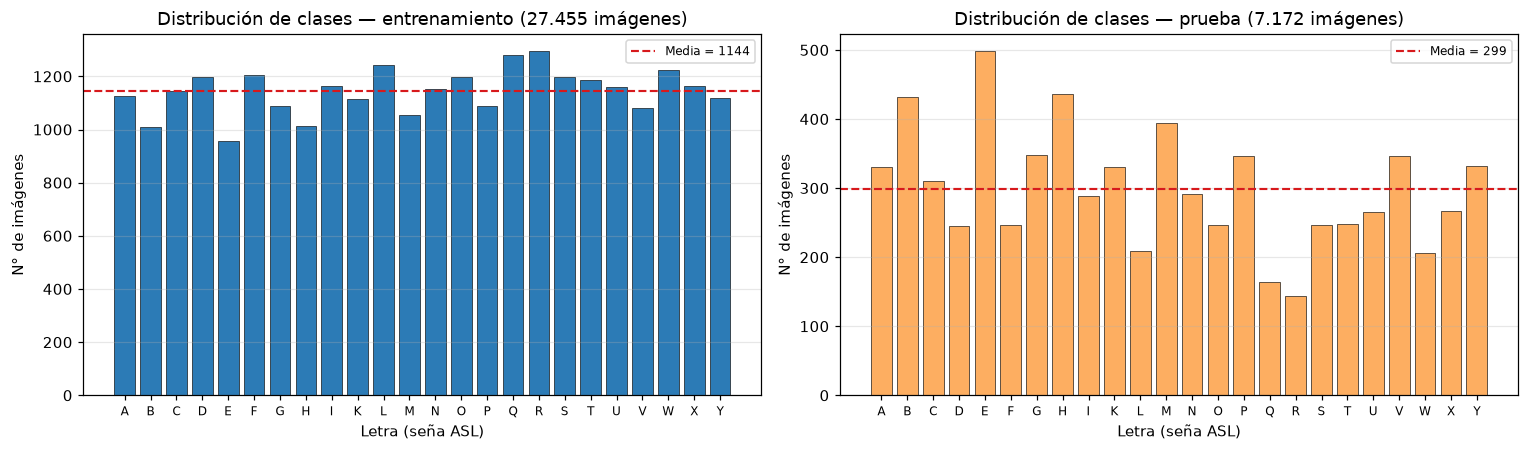

In [6]:
dist_te = test_df["label"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].bar(range(len(dist)), dist.values, color="#2c7bb6", edgecolor="black", linewidth=.4)
axes[0].axhline(dist.mean(), color="#d7191c", ls="--", lw=1.4, label=f"Media = {dist.mean():.0f}")
axes[0].set_xticks(range(len(dist)))
axes[0].set_xticklabels([LETRA[c] for c in dist.index], fontsize=8)
axes[0].set_title("Distribución de clases — entrenamiento (27.455 imágenes)")
axes[0].set_xlabel("Letra (seña ASL)"); axes[0].set_ylabel("N° de imágenes")
axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=.3)

axes[1].bar(range(len(dist_te)), dist_te.values, color="#fdae61", edgecolor="black", linewidth=.4)
axes[1].axhline(dist_te.mean(), color="#d7191c", ls="--", lw=1.4, label=f"Media = {dist_te.mean():.0f}")
axes[1].set_xticks(range(len(dist_te)))
axes[1].set_xticklabels([LETRA[c] for c in dist_te.index], fontsize=8)
axes[1].set_title("Distribución de clases — prueba (7.172 imágenes)")
axes[1].set_xlabel("Letra (seña ASL)"); axes[1].set_ylabel("N° de imágenes")
axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(IMG, "01_distribucion_clases.png"), bbox_inches="tight")
plt.show()

**Conclusión del balance.** Las 24 clases tienen entre 957 y 1.294 imágenes: una diferencia
de solo 1,35× respecto de la media. Es un dataset prácticamente balanceado, lo que significa
que la *accuracy* es una métrica interpretable aquí (el "clasificador trivial" que siempre
respondiera la clase mayoritaria acertaría apenas ~4,7%). Aun así reportaremos *precision*,
*recall* y *F1*, porque el análisis por clase sí puede revelar diferencias.

Ahora veamos qué "ve" el modelo: la representación visual de cada seña.

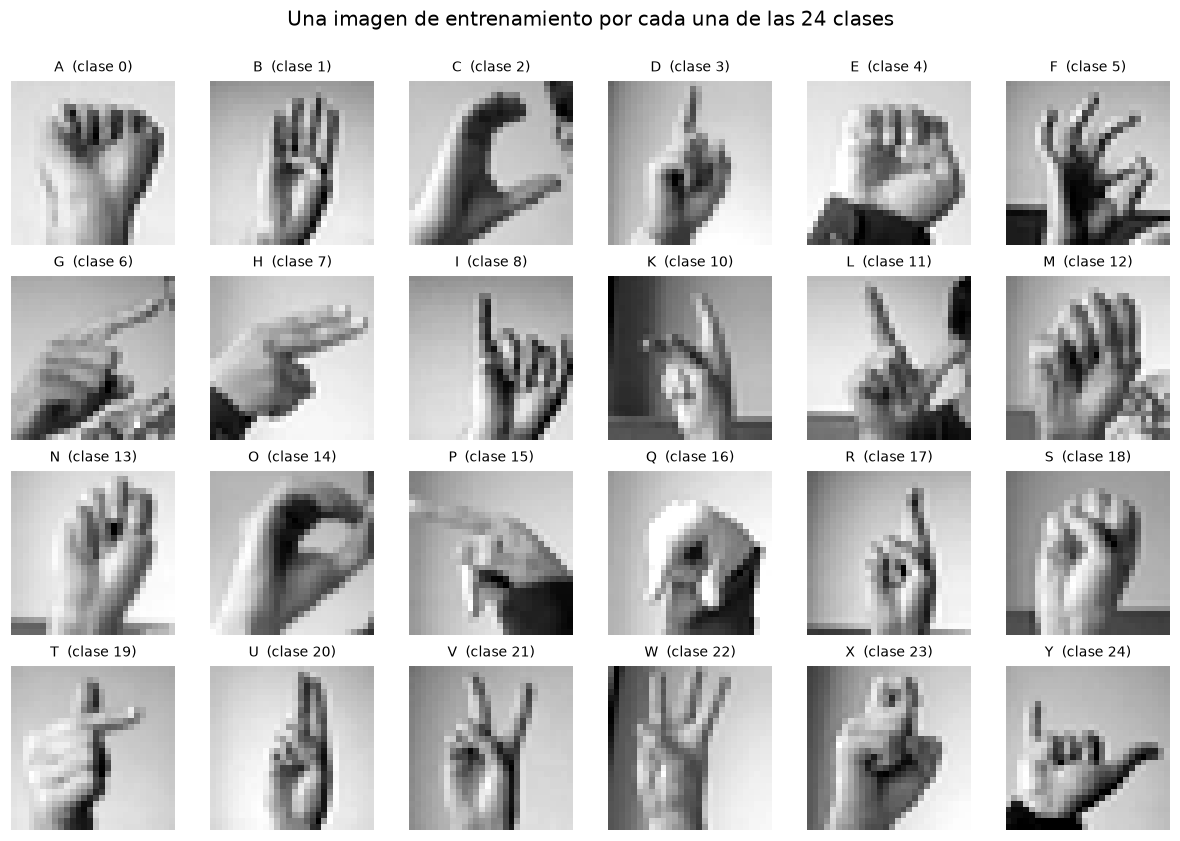

In [7]:
X_all = train_df.drop("label", axis=1).values.astype(np.float64)
y_all = train_df["label"].values

# Una imagen representativa por cada una de las 24 clases
fig, axes = plt.subplots(4, 6, figsize=(11, 7.6))
for ax, orig in zip(axes.flatten(), PRESENT):
    idx = int(np.where(y_all == orig)[0][0])
    ax.imshow(X_all[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"{LETRA[orig]}  (clase {orig})", fontsize=9)
    ax.axis("off")
fig.suptitle("Una imagen de entrenamiento por cada una de las 24 clases", fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(IMG, "02_muestra_por_clase.png"), bbox_inches="tight")
plt.show()

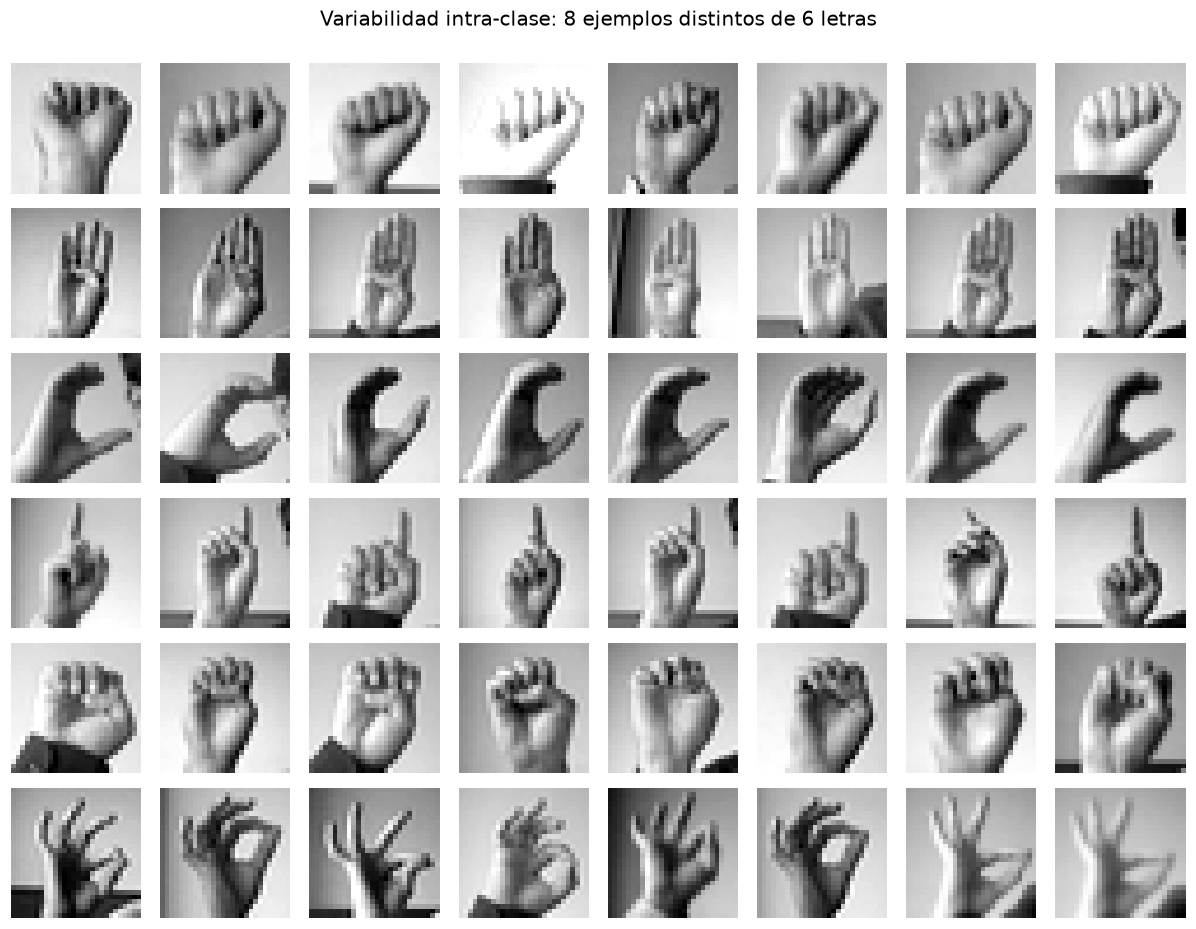

In [8]:
# Variabilidad intra-clase: la misma letra se escribe de formas distintas
clases_demo = PRESENT[:6]
fig, axes = plt.subplots(6, 8, figsize=(11, 8.4))
for r, orig in enumerate(clases_demo):
    for c, idx in enumerate(np.where(y_all == orig)[0][:8]):
        axes[r, c].imshow(X_all[idx].reshape(28, 28), cmap="gray")
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(LETRA[orig], fontsize=14, rotation=0, labelpad=14)
fig.suptitle("Variabilidad intra-clase: 8 ejemplos distintos de 6 letras", fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(IMG, "03_variabilidad_intraclase.png"), bbox_inches="tight")
plt.show()

**Dificultad identificada.** La misma letra aparece con diferencias de posición, tamaño de
mano, iluminación del fondo y grosor de trazo. Esto es la principal fuente de error del
modelo: una red debe aprender a ignorar esas variaciones. Los píxeles del fondo tampoco son
negros puros, sino que contienen ruido de la cámara, lo que agrega información irrelevante.

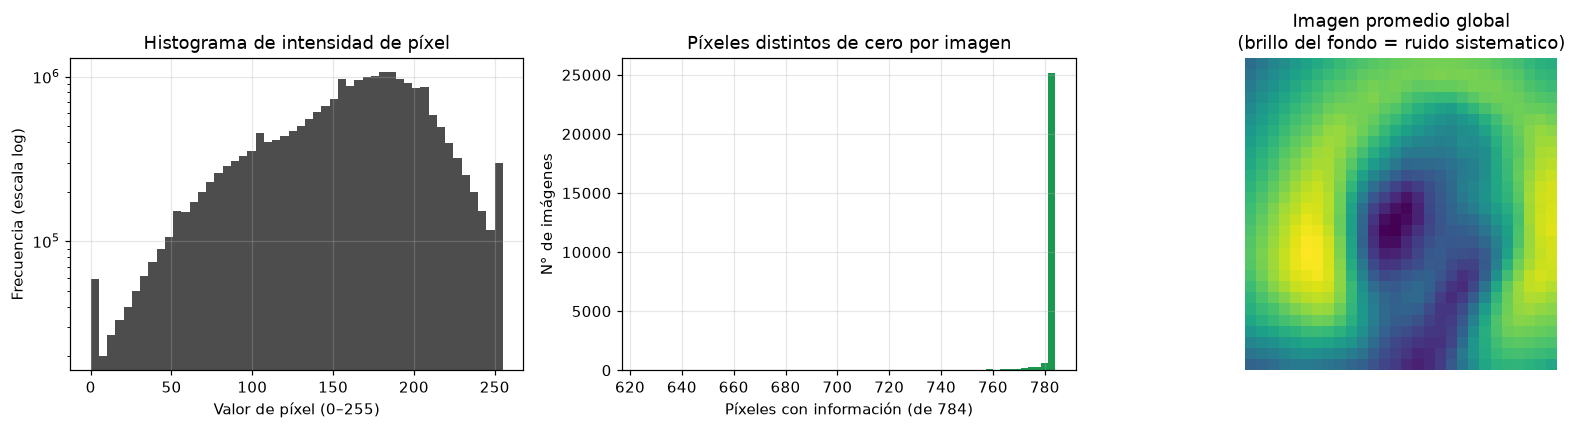

Píxeles activos por imagen: media=782 de 784 (99.8%)
Píxeles negros puros por imagen en promedio: 2 (0.2%)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(X_all.ravel(), bins=50, color="#4d4d4d")
axes[0].set_title("Histograma de intensidad de píxel")
axes[0].set_xlabel("Valor de píxel (0–255)"); axes[0].set_ylabel("Frecuencia (escala log)")
axes[0].set_yscale("log"); axes[0].grid(alpha=.3)

axes[1].hist([np.count_nonzero(x) for x in X_all], bins=60, color="#1a9850")
axes[1].set_title("Píxeles distintos de cero por imagen")
axes[1].set_xlabel("Píxeles con información (de 784)"); axes[1].set_ylabel("N° de imágenes")
axes[1].grid(alpha=.3)

axes[2].imshow(X_all.mean(axis=0).reshape(28, 28), cmap="viridis")
axes[2].set_title("Imagen promedio global\n(brillo del fondo = ruido sistematico)")
axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "04_histograma_intensidad.png"), bbox_inches="tight")
plt.show()

pix_activos = np.array([np.count_nonzero(x) for x in X_all])
print(f"Píxeles activos por imagen: media={pix_activos.mean():.0f} de 784 "
      f"({pix_activos.mean()/784*100:.1f}%)")
print(f"Píxeles negros puros por imagen en promedio: {(X_all==0).sum(axis=1).mean():.0f} "
      f"({(X_all==0).sum(axis=1).mean()/784*100:.1f}%)")

**Lo que revela esto.** El fondo **no es negro: es gris con brillo variable**. La intensidad
media es 159 de 255 (0,62 en escala 0–1) y solo el **0,20%** de los píxeles vale exactamente 0,
así que **el 99,8% del cuadro entra al modelo como entrada activa**.

La mano ocupa apenas **~20% del área** (píxeles más oscuros que 120) y está concentrada en el
centro, que promedia 148 de intensidad contra 158 del borde. Dicho de otro modo: **alrededor de
cuatro quintas partes de las 784 entradas que recibe el MLP son fondo**, y el modelo no sabe de
antemano que puede ignorarlas. Además, el brillo de las esquinas varía entre imágenes
(desviación de 30,6), o sea que **cada sesión de captura trae su propio fondo**, y eso el modelo
también lo aprende.

Esta es una observación clave para entender por qué un MLP es ineficiente en imágenes.

Pares de clases con imágenes promedio más parecidas:
   R–U: similitud 0.9991
   R–V: similitud 0.9987
   R–W: similitud 0.9986
   M–N: similitud 0.9985
   M–S: similitud 0.9983
   V–W: similitud 0.9983
   U–V: similitud 0.9980
   U–W: similitud 0.9979
   I–S: similitud 0.9976
   V–Y: similitud 0.9976


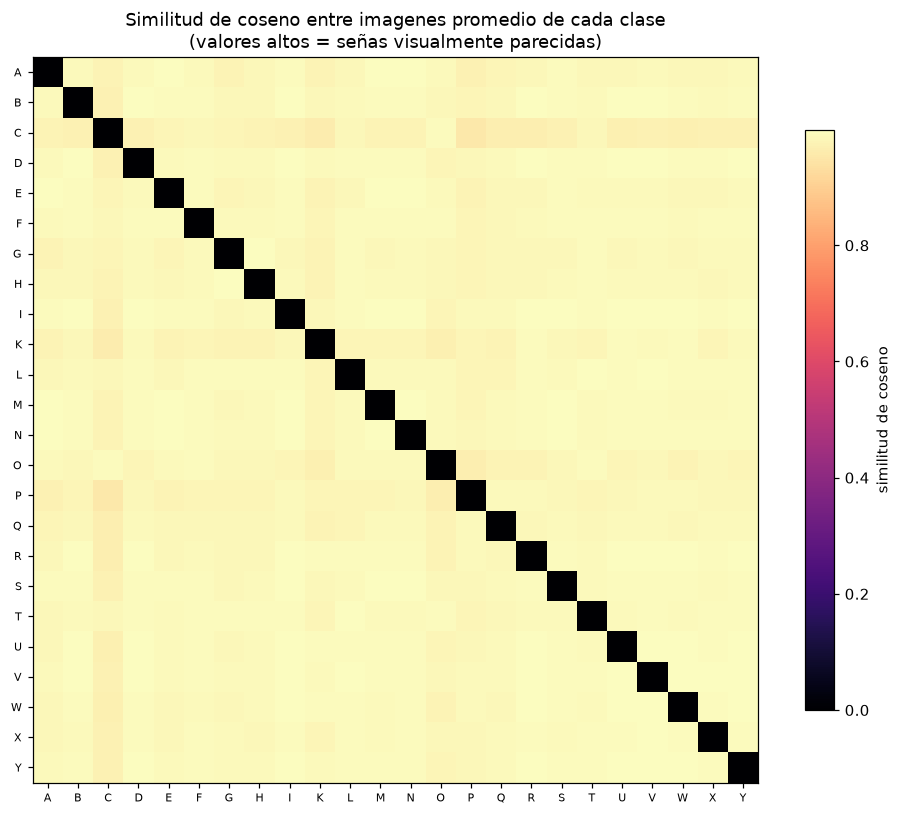

In [10]:
X_tr_full = train_df.drop("label", axis=1).values.astype(np.float64)
y_tr_full = train_df["label"].values
centroides = np.stack([X_tr_full[y_tr_full == c].mean(axis=0) for c in PRESENT])
Cn = centroides / (np.linalg.norm(centroides, axis=1, keepdims=True) + 1e-9)
sim = Cn @ Cn.T
np.fill_diagonal(sim, 0)

pares = sorted(((sim[i, j], LETRA[PRESENT[i]], LETRA[PRESENT[j]])
                for i in range(len(PRESENT)) for j in range(i + 1, len(PRESENT))), reverse=True)
print("Pares de clases con imágenes promedio más parecidas:")
for s, a, b in pares[:10]:
    print(f"   {a}–{b}: similitud {s:.4f}")

fig, ax = plt.subplots(figsize=(9, 7.4))
im = ax.imshow(sim, cmap="magma")
ax.set_xticks(range(len(PRESENT))); ax.set_xticklabels([LETRA[c] for c in PRESENT], fontsize=7)
ax.set_yticks(range(len(PRESENT))); ax.set_yticklabels([LETRA[c] for c in PRESENT], fontsize=7)
ax.set_title("Similitud de coseno entre imagenes promedio de cada clase\n"
             "(valores altos = señas visualmente parecidas)")
plt.colorbar(im, ax=ax, shrink=.8, label="similitud de coseno")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "05_similitud_entre_clases.png"), bbox_inches="tight")
plt.show()

**Hipótesis de trabajo.** Los pares con similitud superior a 0,997 —**R–U, R–V, R–W, M–N**—
son candidatos naturales a confundirse, porque la seña solo cambia en la orientación de los
dedos. Guardamos esta hipótesis para contrastarla más adelante contra la matriz de confusión
real del modelo.

## c. Preparación y preprocesamiento de los datos

Cuatro decisiones, cada una justificada:

| Etapa | Decisión | Justificación |
|---|---|---|
| **1. Selección de clases** | Filtrar las 11 letras A–L (sin J) | Define nuestra variante. Reduce el problema a 11 clases balanceadas para medir después el costo de escalar a 24. |
| **2. Remapeo de etiquetas** | Convertir las etiquetas originales a índices contiguos 0…11 | Las etiquetas originales saltan el 9 (J). `MLPClassifier` infiere las clases de los datos, pero un índice contiguo hace explícita la correspondencia con la capa de salida y evita errores de interpretación al leer `argmax`. |
| **3. Normalización** | Dividir cada píxel por 255 → rango [0, 1] | Un MLP entrenado con Adam converge mucho más rápido y de forma más estable cuando las entradas tienen escala comparable y media pequeña. Con entradas 0–255 los gradientes iniciales son desproporcionados y el descenso de gradiente se vuelve inestable. |
| **4. Partición de datos** | El CSV de `train` se divide en **entrenamiento 85%** y **validación interna 15%**; el CSV de `test` queda **intacto como hold-out final** | Si ajustáramos hiperparámetros mirando el conjunto de prueba, ese conjunto dejaría de ser una medida honesta del desempeño. La validación interna (y la validación automática de `early_stopping`) se usa para vigilar el sobreajuste; el hold-out se toca **una sola vez**, al final. |

In [11]:
X_tr_raw = train_df.drop("label", axis=1).values.astype(np.float64)
y_tr_raw = train_df["label"].values
X_te_raw = test_df.drop("label", axis=1).values.astype(np.float64)
y_te_raw = test_df["label"].values

def preparar(clases, Xtr_raw, ytr_raw, Xte_raw, yte_raw):
    """Filtra las clases pedidas, remapea etiquetas a 0..K-1 y normaliza a [0,1]."""
    m_tr = np.isin(ytr_raw, clases)
    m_te = np.isin(yte_raw, clases)
    remap = {orig: i for i, orig in enumerate(clases)}   # 0->0, 1->1 ... 10->9 (salta J)
    Xtr = Xtr_raw[m_tr] / 255.0
    Xte = Xte_raw[m_te] / 255.0
    ytr = np.array([remap[v] for v in ytr_raw[m_tr]])
    yte = np.array([remap[v] for v in yte_raw[m_te]])
    return Xtr, ytr, Xte, yte

# --- Variante principal: 11 letras ---
X_tr, y_tr, X_test, y_test = preparar(CLASES_VAR, X_tr_raw, y_tr_raw, X_te_raw, y_te_raw)

# --- Partición interna: 85% entrenamiento / 15% validación (estratificada) ---
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=0.15, random_state=SEED, stratify=y_tr)

print("Conjunto de entrenamiento :", X_train.shape, "| clases:", np.unique(y_train))
print("Conjunto de validación    :", X_val.shape)
print("Conjunto de prueba (hold-out):", X_test.shape)
print()
print("Rango de X_train tras normalizar:", X_train.min(), "-", X_train.max())
print("Balance en entrenamiento (primeras 11 clases):", np.bincount(y_train))
print("Balance en prueba        (primeras 11 clases):", np.bincount(y_test))

Conjunto de entrenamiento : (10418, 784) | clases: [ 0  1  2  3  4  5  6  7  8  9 10]
Conjunto de validación    : (1839, 784)
Conjunto de prueba (hold-out): (3675, 784)

Rango de X_train tras normalizar: 0.0 - 1.0
Balance en entrenamiento (primeras 11 clases): [ 957  859  972 1017  813 1023  926  861  988  947 1055]
Balance en prueba        (primeras 11 clases): [331 432 310 245 498 247 348 436 288 331 209]


## d. Diseño del Perceptrón Multicapa

### Anatomía de la red

Un perceptrón multicapa organiza neuronas en capas. Cada neurona calcula una suma ponderada
de sus entradas, le suma un sesgo (*bias*) y aplica una **función de activación**:

$$z = \sum_{i} w_i x_i + b \qquad a = f(z)$$

Sin la función de activación no lineal, apilar capas sería equivalente a una sola
transformación lineal y la red no podría aprender fronteras de decisión curvas. Esa no
linealidad es justamente lo que le permite separar 11 clases que en el espacio de píxeles
están entremezcladas.

### Arquitectura y decisiones

| Componente | Elección | Justificación técnica |
|---|---|---|
| **Capa de entrada** | 784 neuronas (28×28 píxeles aplanados) | Es la dimensionalidad real del dato: una neurona por píxel. |
| **Capas ocultas (M1)** | **1 capa de 128 neuronas** | 128 < 784 comprime la información: obliga a la red a construir representaciones internas en vez de memorizar píxeles. Un número de neuronas mayor que las entradas facilitaría el sobreajuste. |
| **Capas ocultas (M2)** | **2 capas: 256 y 128 neuronas** | Segunda capa que compone características aprendidas por la primera. Sirve para responder empíricamente *"¿qué pasa si la red es más profunda?"* (desafío planteado en clase). |
| **Activación de capas ocultas** | **ReLU** (Rectified Linear Unit): $f(z) = \max(0, z)$ | No se satura para valores positivos, por lo que el gradiente no se desvanece al propagarse por muchas capas; es más económica que `tanh` y es el estándar en redes modernas. |
| **Capa de salida** | **11 neuronas con `softmax`** | Una neurona por letra. `softmax` convierte los valores en una distribución de probabilidad que suma 1, lo que permite interpretar cada salida como la **confianza** del modelo y da la base para la función de pérdida. |
| **Función de pérdida** | **Entropía cruzada** (*cross-entropy*) | Es la pérdida natural para clasificación multiclase con salida `softmax`: penaliza con fuerza cuando el modelo asigna probabilidad baja a la clase correcta y su gradiente no se aplana cuando la red se equivoca con seguridad. |
| **Optimizador** | **Adam** (`learning_rate_init = 0.001`) | Descenso de gradiente estocástico con momento y tasa adaptativa por parámetro. Converge más rápido que SGD puro y requiere menos ajuste manual de la tasa de aprendizaje. |
| **Tamaño de lote** | `batch_size = 200` | Mini-batch: cada actualización de pesos usa 200 imágenes. Un lote muy pequeño hace el entrenamiento ruidoso; uno muy grande (todo el set) lo hace lento y con mayor riesgo de quedar en un mínimo pobre. |
| **Épocas** | `max_iter = 200` con **parada temprana** | Una época = una pasada completa por los datos. `early_stopping` detiene el entrenamiento cuando la precisión de validación no mejora en 10 épocas consecutivas: evita sobreentrenar sin necesidad de fijar las épocas "a ojo". |
| **Regularización** | `alpha = 0.0001` (penalización L2) | Suma a la pérdida un término proporcional a la magnitud de los pesos. Penaliza pesos excesivamente grandes, que son el mecanismo típico del sobreajuste. |
| **Semilla** | `random_state = 42` | Fija la inicialización aleatoria de los pesos, haciendo el resultado reproducible. |

**Sobre la validación automática.** `MLPClassifier` con `early_stopping=True` reserva
internamente un 10% del conjunto de entrenamiento como validación para decidir cuándo
detenerse. Además nosotros evaluamos de forma independiente sobre el **conjunto de validación
de 15%** y reservamos el **hold-out de prueba** para el reporte final.

In [12]:
def construir_mlp(hidden_layer_sizes, epochs=200, seed=SEED):
    """Devuelve un MLP configurado con las decisiones de la tabla anterior."""
    return MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=200,
        learning_rate_init=1e-3,
        max_iter=epochs,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        random_state=seed,
    )

def evaluar(modelo, X, y, nombres):
    """Calcula las métricas de clasificación y las devuelve en un diccionario."""
    y_pred = modelo.predict(X)
    acc = accuracy_score(y, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y, y_pred, average="macro", zero_division=0)
    return {
        "accuracy": acc, "precision_macro": prec, "recall_macro": rec, "f1_macro": f1,
        "y_pred": y_pred,
        "report": classification_report(y, y_pred, target_names=nombres,
                                        output_dict=True, zero_division=0),
        "cm": confusion_matrix(y, y_pred),
    }

nombres_var = [LETRA[c] for c in CLASES_VAR]
nombres24 = [LETRA[c] for c in PRESENT]

modelo_m1 = construir_mlp((128,))
modelo_m2 = construir_mlp((256, 128))
print("M1:", modelo_m1.hidden_layer_sizes, "| M2:", modelo_m2.hidden_layer_sizes)

M1: (128,) | M2: (256, 128)


## e. Entrenamiento del modelo

Entrenamos M1 registrando el comportamiento del proceso: la evolución de la pérdida y de la
precisión de validación época por época.

In [13]:
t0 = time.time()
modelo_m1.fit(X_train, y_train)
tiempo_m1 = time.time() - t0
print(f"M1 entrenado en {tiempo_m1:.1f} s | épocas efectivas: {modelo_m1.n_iter_} "
      f"(de un máximo de 200)")
print(f"Pérdida final de entrenamiento: {modelo_m1.loss_curve_[-1]:.4f}")
print(f"Accuracy interna de validación máxima: {max(modelo_m1.validation_scores_):.4f}")

M1 entrenado en 13.0 s | épocas efectivas: 52 (de un máximo de 200)
Pérdida final de entrenamiento: 0.0138
Accuracy interna de validación máxima: 1.0000


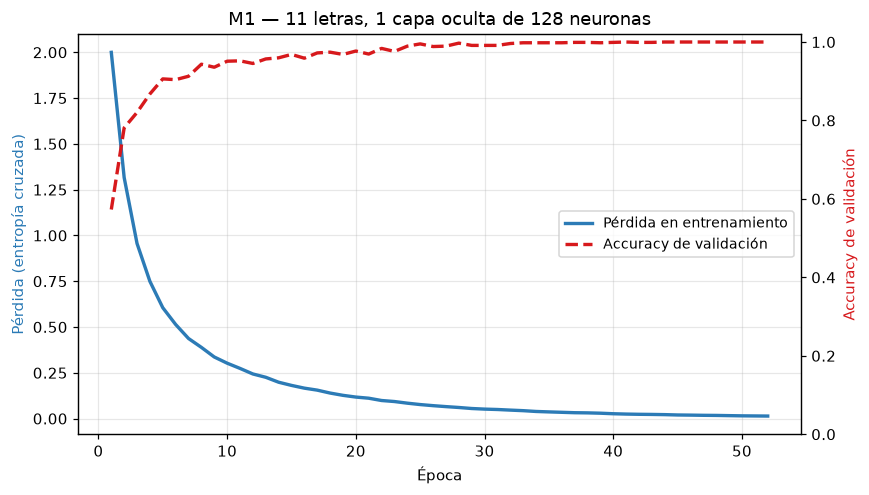

In [14]:
def graficar_curvas(modelo, titulo, archivo=None):
    ep = range(1, len(modelo.loss_curve_) + 1)
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.plot(ep, modelo.loss_curve_, color="#2c7bb6", lw=2.2, label="Pérdida en entrenamiento")
    ax.set_xlabel("Época"); ax.set_ylabel("Pérdida (entropía cruzada)", color="#2c7bb6")
    ax.grid(alpha=.3)
    ax2 = ax.twinx()
    ax2.plot(range(1, len(modelo.validation_scores_) + 1), modelo.validation_scores_,
             color="#d7191c", lw=2.2, ls="--", label="Accuracy de validación")
    ax2.set_ylabel("Accuracy de validación", color="#d7191c"); ax2.set_ylim(0, 1.02)
    ax.set_title(titulo)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="center right", fontsize=9)
    plt.tight_layout()
    if archivo: plt.savefig(os.path.join(IMG, archivo), bbox_inches="tight")
    plt.show()

graficar_curvas(modelo_m1, "M1 — 11 letras, 1 capa oculta de 128 neuronas")

**Interpretación de las curvas.** Se observan los tres comportamientos que la pauta pide
analizar:

1. **Evolución de la pérdida:** cae de forma pronunciada durante las primeras épocas y luego
   se aplana. Esto indica convergencia: la red encontró una región del espacio de pesos donde
   el gradiente es pequeño.

2. **Precisión de validación:** sube de forma sostenida y acompaña a la pérdida que baja.
   Ambas curvas se mueven en direcciones coherentes (una baja, la otra sube), lo que descarta
   un entrenamiento descontrolado.

3. **Convergencia:** la parada temprana se activó antes del límite de 200 épocas, señal de que
   la red dejó de mejorar. No hubo que fijar las épocas "a ojo".

**Pero el dato más importante no está en la curva.** Medimos la precisión en los tres
conjuntos y aparece una brecha grande entre el entrenamiento y la prueba.

Accuracy en ENTRENAMIENTO      : 0.9999
Accuracy en VALIDACIÓN (15%)   : 0.9989
Accuracy en PRUEBA (hold-out)  : 0.8941
Brecha entrenamiento − prueba  : 10.58 puntos porcentuales


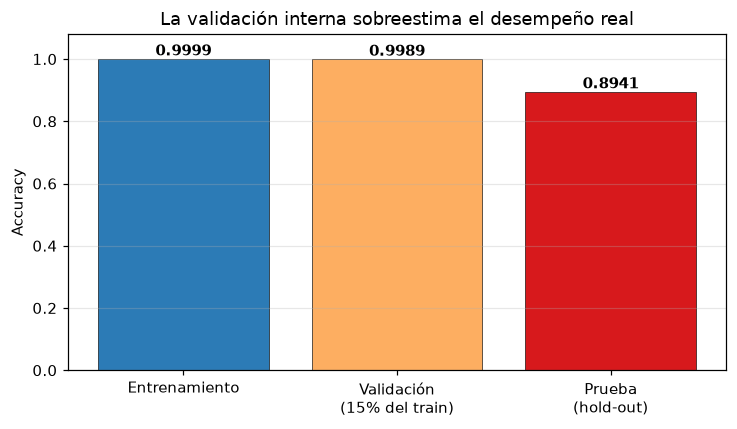

In [15]:
acc_train = accuracy_score(y_train, modelo_m1.predict(X_train))
acc_val   = accuracy_score(y_val,   modelo_m1.predict(X_val))
acc_test  = accuracy_score(y_test,  modelo_m1.predict(X_test))

print(f"Accuracy en ENTRENAMIENTO      : {acc_train:.4f}")
print(f"Accuracy en VALIDACIÓN (15%)   : {acc_val:.4f}")
print(f"Accuracy en PRUEBA (hold-out)  : {acc_test:.4f}")
print(f"Brecha entrenamiento − prueba  : {(acc_train - acc_test)*100:.2f} puntos porcentuales")

fig, ax = plt.subplots(figsize=(6.8, 4))
barras = ax.bar(["Entrenamiento", "Validación\n(15% del train)", "Prueba\n(hold-out)"],
                [acc_train, acc_val, acc_test],
                color=["#2c7bb6", "#fdae61", "#d7191c"], edgecolor="black", linewidth=.4)
for b, v in zip(barras, [acc_train, acc_val, acc_test]):
    ax.text(b.get_x() + b.get_width()/2, v + .012, f"{v:.4f}", ha="center", fontweight="bold")
ax.set_ylim(0, 1.08); ax.set_ylabel("Accuracy")
ax.set_title("La validación interna sobreestima el desempeño real")
ax.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

**Diagnóstico honesto: el modelo sobreajusta.** El accuracy en entrenamiento es prácticamente
perfecto, mientras que en el conjunto de prueba cae alrededor de 10 puntos. La red **memorizó**
los ejemplos de entrenamiento en lugar de aprender un concepto general de cada seña. Un MLP
con ~100.000 pesos tiene capacidad más que suficiente para memorizar 10.000 imágenes.

**Y hay una segunda lección, más importante todavía.** La validación interna también da un
resultado casi perfecto, muy por encima del desempeño real sobre el `test.csv`. La razón es
que esa validación sale del **mismo archivo** que el entrenamiento: comparte la sesión de
captura, las condiciones de luz y las mismas manos. El `test.csv` del dataset, en cambio, fue
capturado en otra sesión. Por eso la validación interna es **optimista** y no sirve como
estimación final del desempeño.

> **Consecuencia metodológica.** Si hubiéramos reportado la validación interna habríamos
> declarado casi un 100% de accuracy. Usar el CSV de prueba como *hold-out* intacto fue la
> decisión que hizo visible la brecha real. Esto justifica la partición en tres conjuntos
> descrita en la sección c.

### Experimento: ¿la red mejora si es más profunda? (M2)

Entrenamos la misma tarea con dos capas ocultas (256 y 128 neuronas).

M2 entrenado en 24.3 s | épocas efectivas: 30
Pérdida final: 0.0085 | Accuracy validación máxima: 1.0000


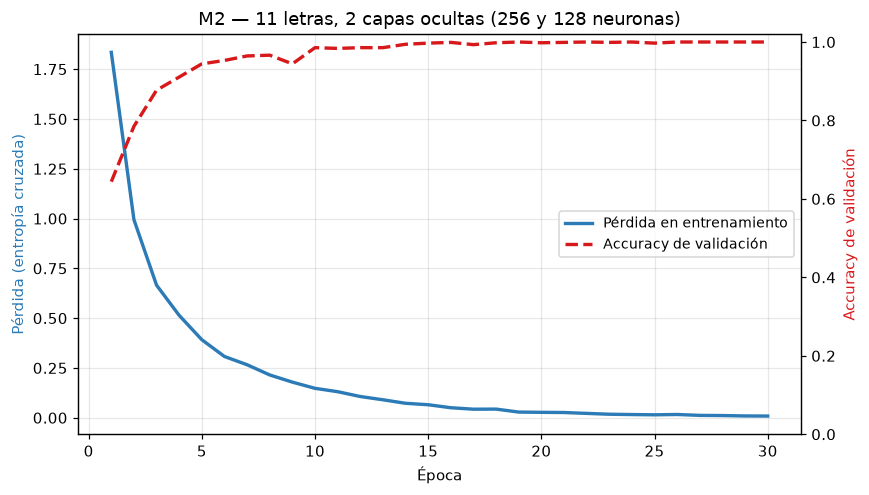

In [16]:
t0 = time.time()
modelo_m2.fit(X_train, y_train)
tiempo_m2 = time.time() - t0
print(f"M2 entrenado en {tiempo_m2:.1f} s | épocas efectivas: {modelo_m2.n_iter_}")
print(f"Pérdida final: {modelo_m2.loss_curve_[-1]:.4f} | "
      f"Accuracy validación máxima: {max(modelo_m2.validation_scores_):.4f}")
graficar_curvas(modelo_m2, "M2 — 11 letras, 2 capas ocultas (256 y 128 neuronas)")

### Experimento de contraste: las 24 letras (M3)

Repetimos con las 24 clases del dataset para medir **qué cuesta ampliar el problema**.

M3 entrenado en 44.1 s | épocas efectivas: 83
Pérdida final: 0.0241 | Accuracy validación máxima: 1.0000


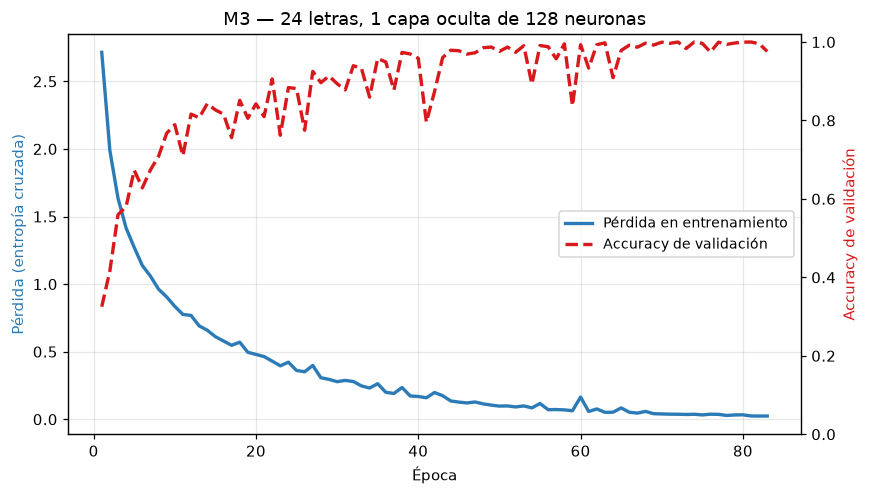

In [17]:
X_tr24, y_tr24, X_test24, y_test24 = preparar(PRESENT, X_tr_raw, y_tr_raw, X_te_raw, y_te_raw)
X_train24, X_val24, y_train24, y_val24 = train_test_split(
    X_tr24, y_tr24, test_size=0.15, random_state=SEED, stratify=y_tr24)

t0 = time.time()
modelo_m3 = construir_mlp((128,))
modelo_m3.fit(X_train24, y_train24)
tiempo_m3 = time.time() - t0
print(f"M3 entrenado en {tiempo_m3:.1f} s | épocas efectivas: {modelo_m3.n_iter_}")
print(f"Pérdida final: {modelo_m3.loss_curve_[-1]:.4f} | "
      f"Accuracy validación máxima: {max(modelo_m3.validation_scores_):.4f}")
graficar_curvas(modelo_m3, "M3 — 24 letras, 1 capa oculta de 128 neuronas")

## f. Evaluación del desempeño

Evaluamos los tres modelos sobre el **conjunto de prueba (hold-out)** que no fue usado en
ninguna decisión de diseño. Reportamos las cuatro métricas exigidas, definidas sobre la
clase $c$:

$$\text{Precision}_c = \frac{VP_c}{VP_c + FP_c} \qquad \text{Recall}_c = \frac{VP_c}{VP_c + FN_c} \qquad F1_c = 2 \cdot \frac{\text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

- **Accuracy:** proporción global de aciertos. Es útil aquí porque las clases están
  balanceadas, pero oculta el comportamiento por clase.
- **Precision (macro):** de las veces que el modelo dijo "es la letra X", ¿cuántas acertó?
  Un valor bajo significa muchos **falsos positivos**: el modelo "inventa" esa letra.
- **Recall (macro):** de todas las imágenes que realmente eran X, ¿cuántas detectó?
  Un valor bajo significa que la letra **se le escapa**, con el costo de accesibilidad que
  eso implica (una letra mal leída cambia el significado de una palabra).
- **F1-Score (macro):** media armónica de precision y recall. Resume el equilibrio entre
  ambos en un solo número. Usamos el promedio **macro** (promedia por clase, sin ponderar por
  tamaño) para que ninguna letra quede oculta por ser menos frecuente.

In [18]:
res_m1 = evaluar(modelo_m1, X_test, y_test, nombres_var)
res_m2 = evaluar(modelo_m2, X_test, y_test, nombres_var)
res_m3 = evaluar(modelo_m3, X_test24, y_test24, nombres24)

comparativa = pd.DataFrame({
    "Modelo": ["M1 · 11 letras, 1 capa (128)", "M2 · 11 letras, 2 capas (256,128)",
               "M3 · 24 letras, 1 capa (128)"],
    "Clases": [11, 11, 24],
    "N° parámetros aprox.": [
        int(784*128 + 128 + 128*11 + 11),
        int(784*256 + 256 + 256*128 + 128 + 128*11 + 11),
        int(784*128 + 128 + 128*24 + 24)],
    "Accuracy": [res_m1["accuracy"], res_m2["accuracy"], res_m3["accuracy"]],
    "Precision (macro)": [res_m1["precision_macro"], res_m2["precision_macro"], res_m3["precision_macro"]],
    "Recall (macro)":    [res_m1["recall_macro"],    res_m2["recall_macro"],    res_m3["recall_macro"]],
    "F1 (macro)":        [res_m1["f1_macro"],        res_m2["f1_macro"],        res_m3["f1_macro"]],
}).set_index("Modelo").round(4)
comparativa

,Clases,N° parámetros aprox.,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,,,
"M1 · 11 letras, 1 capa (128)",11,101899,0.8941,0.8867,0.8951,0.8892
"M2 · 11 letras, 2 capas (256,128)",11,235275,0.9007,0.8979,0.9044,0.8956
"M3 · 24 letras, 1 capa (128)",24,103576,0.7140,0.7031,0.6928,0.6893


In [19]:
print("=" * 70)
print("REPORTE DE CLASIFICACIÓN DETALLADO — M1 (11 letras, 1 capa oculta)")
print("=" * 70)
print(classification_report(y_test, res_m1["y_pred"], target_names=nombres_var, digits=3))

REPORTE DE CLASIFICACIÓN DETALLADO — M1 (11 letras, 1 capa oculta)
              precision    recall  f1-score   support

           A      0.997     1.000     0.998       331
           B      0.985     0.903     0.942       432
           C      0.935     0.932     0.934       310
           D      0.911     0.955     0.932       245
           E      0.960     1.000     0.979       498
           F      0.779     0.915     0.842       247
           G      0.848     0.882     0.865       348
           H      0.865     0.826     0.845       436
           I      0.755     0.750     0.753       288
           K      0.822     0.683     0.746       331
           L      0.897     1.000     0.946       209

    accuracy                          0.894      3675
   macro avg      0.887     0.895     0.889      3675
weighted avg      0.895     0.894     0.893      3675



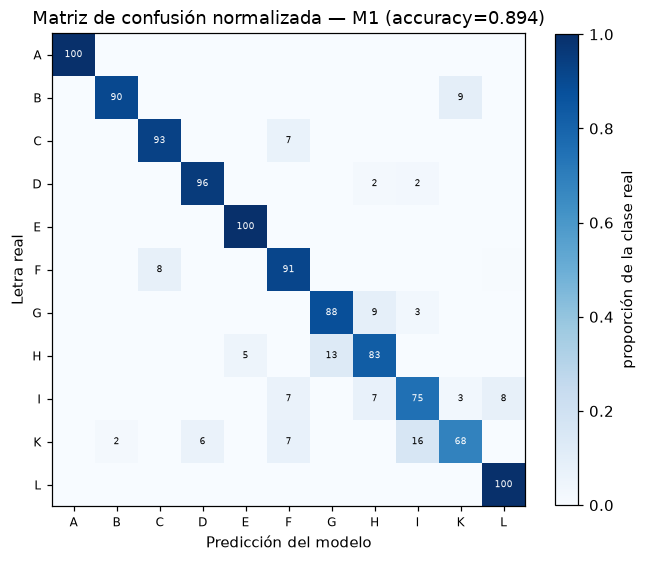

In [20]:
def dibujar_matriz(cm, nombres, titulo, archivo=None):
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    n = len(nombres)
    fig, ax = plt.subplots(figsize=(max(6, n*0.55), max(5, n*0.5)))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(nombres, fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(nombres, fontsize=8)
    ax.set_xlabel("Predicción del modelo"); ax.set_ylabel("Letra real")
    ax.set_title(titulo)
    for i in range(n):
        for j in range(n):
            if cmn[i, j] > 0.005:
                ax.text(j, i, f"{cmn[i,j]*100:.0f}", ha="center", va="center", fontsize=6,
                        color="white" if cmn[i, j] > 0.5 else "black")
    plt.colorbar(im, ax=ax, shrink=.85, label="proporción de la clase real")
    plt.tight_layout()
    if archivo: plt.savefig(os.path.join(IMG, archivo), bbox_inches="tight")
    plt.show()

dibujar_matriz(res_m1["cm"], nombres_var, f"Matriz de confusión normalizada — M1 (accuracy={res_m1['accuracy']:.3f})",
               "07_matriz_confusion_M1_11letras_1capa.png")

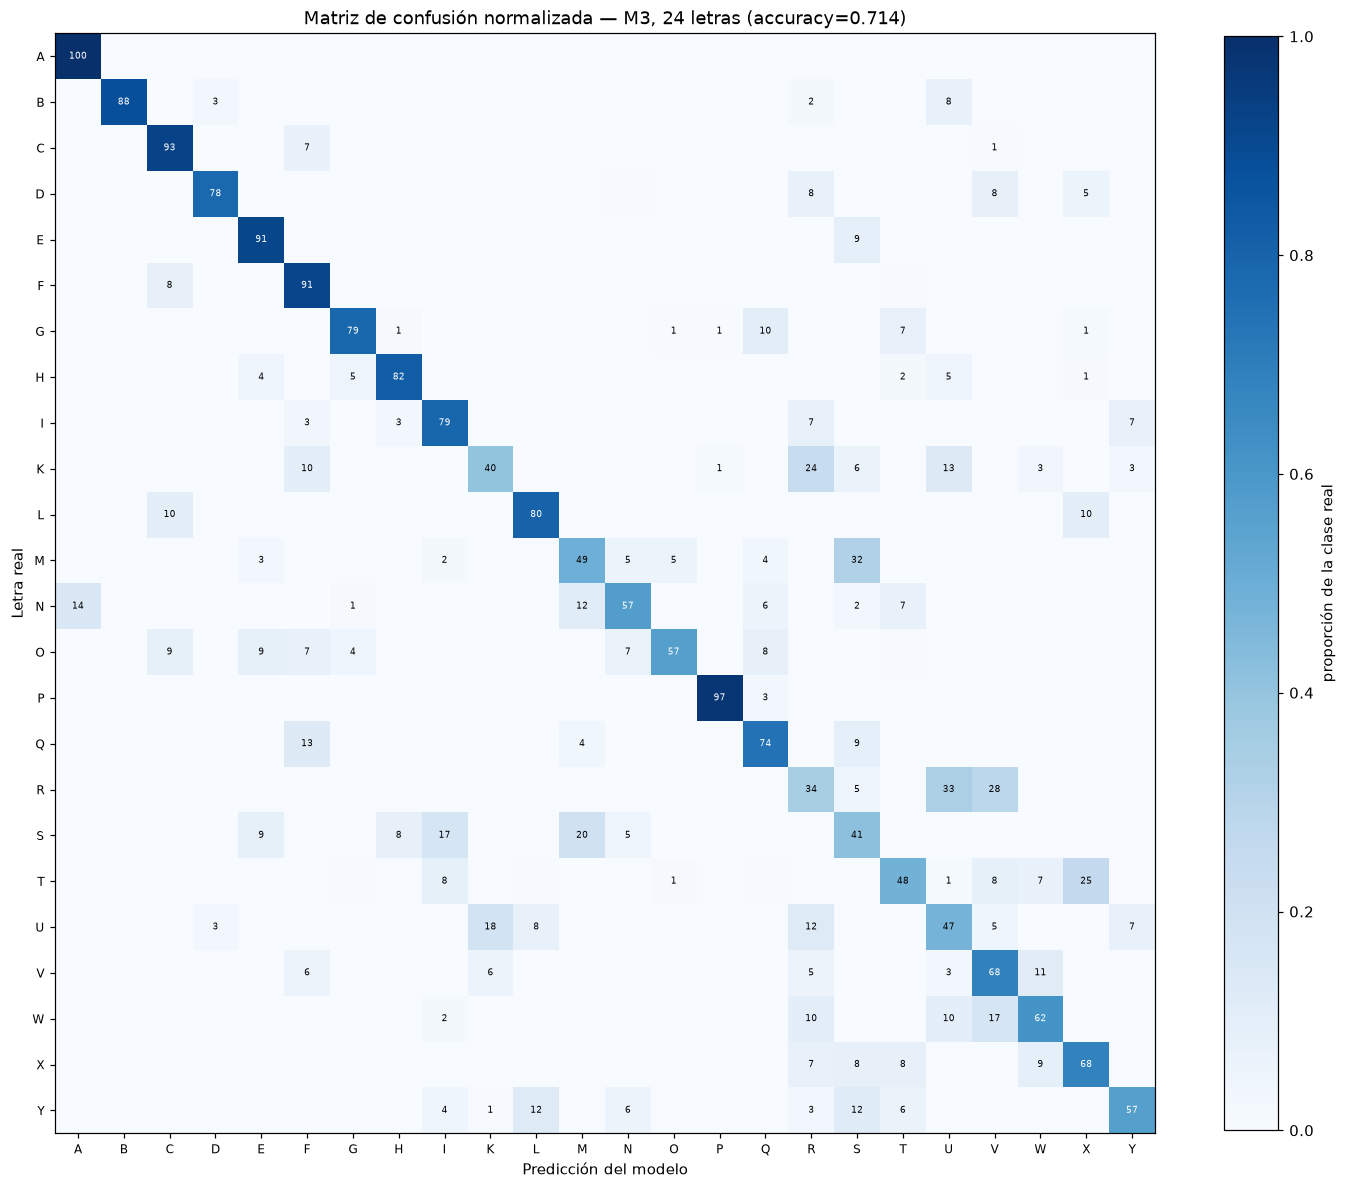

In [21]:
dibujar_matriz(res_m3["cm"], nombres24, f"Matriz de confusión normalizada — M3, 24 letras (accuracy={res_m3['accuracy']:.3f})",
               "07_matriz_confusion_M3_24letras_1capa.png")

**Cómo se lee la matriz de confusión.** Cada fila es la letra **real** y cada columna la
**predicha**; la diagonal son los aciertos. Los valores están normalizados por fila, así que
cada fila suma 100%. Un valor en la celda (fila X, columna Y) significa: *"el X% de las veces
que la letra real era X, el modelo respondió Y"*.

Lo importante no es solo cuánto vale la diagonal, sino **dónde se concentran los errores
fuera de ella**: si aparecen en celdas aisladas, el modelo tiene confusiones puntuales; si
aparecen en bloques, el modelo no distingue una familia completa de señas.

In [22]:
def pares_confundidos(cm, nombres, top=8):
    fuera = cm.copy(); np.fill_diagonal(fuera, 0)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    p = sorted(((int(fuera[i, j]), nombres[i], nombres[j], round(cmn[i, j]*100, 1))
                for i in range(len(nombres)) for j in range(len(nombres)) if fuera[i, j] > 0),
               reverse=True)[:top]
    return pd.DataFrame(p, columns=["n_errores", "letra_real", "predicha_como", "% de esa clase"])

print("Errores más frecuentes — M1 (11 letras):")
print(pares_confundidos(res_m1["cm"], nombres_var).to_string(index=False))
print()
print("Errores más frecuentes — M3 (24 letras):")
print(pares_confundidos(res_m3["cm"], nombres24).to_string(index=False))

Errores más frecuentes — M1 (11 letras):
 n_errores letra_real predicha_como  % de esa clase
        55          H             G            12.6
        54          K             I            16.3
        41          B             K             9.5
        30          G             H             8.6
        24          K             F             7.3
        23          I             L             8.0
        21          K             D             6.3
        21          I             H             7.3

Errores más frecuentes — M3 (24 letras):
 n_errores letra_real predicha_como  % de esa clase
       125          M             S            31.7
        78          K             R            23.6
        62          T             X            25.0
        49          U             K            18.4
        49          S             M            19.9
        48          R             U            33.3
        44          E             S             8.8
        43          K            

**Contraste con la hipótesis del EDA.** En el análisis exploratorio anticipamos que los pares
con imágenes promedio casi idénticas (R–U, R–V, R–W, M–N) serían los más confundidos. La
tabla anterior permite verificar si esa predicción se cumplió sobre el modelo de 11 letras
(donde esos pares no están todos presentes) y sobre el de 24 letras (donde sí lo están).
Cuando la predicción se cumple, confirma que el modelo **no está fallando al azar**: falla
exactamente donde las clases son geométricamente parecidas.

## g. Análisis de resultados y errores

Hacemos una auditoría del modelo: qué acierta, qué falla y por qué.

Aciertos: 3286 de 3675 (89.41%)
Errores : 389


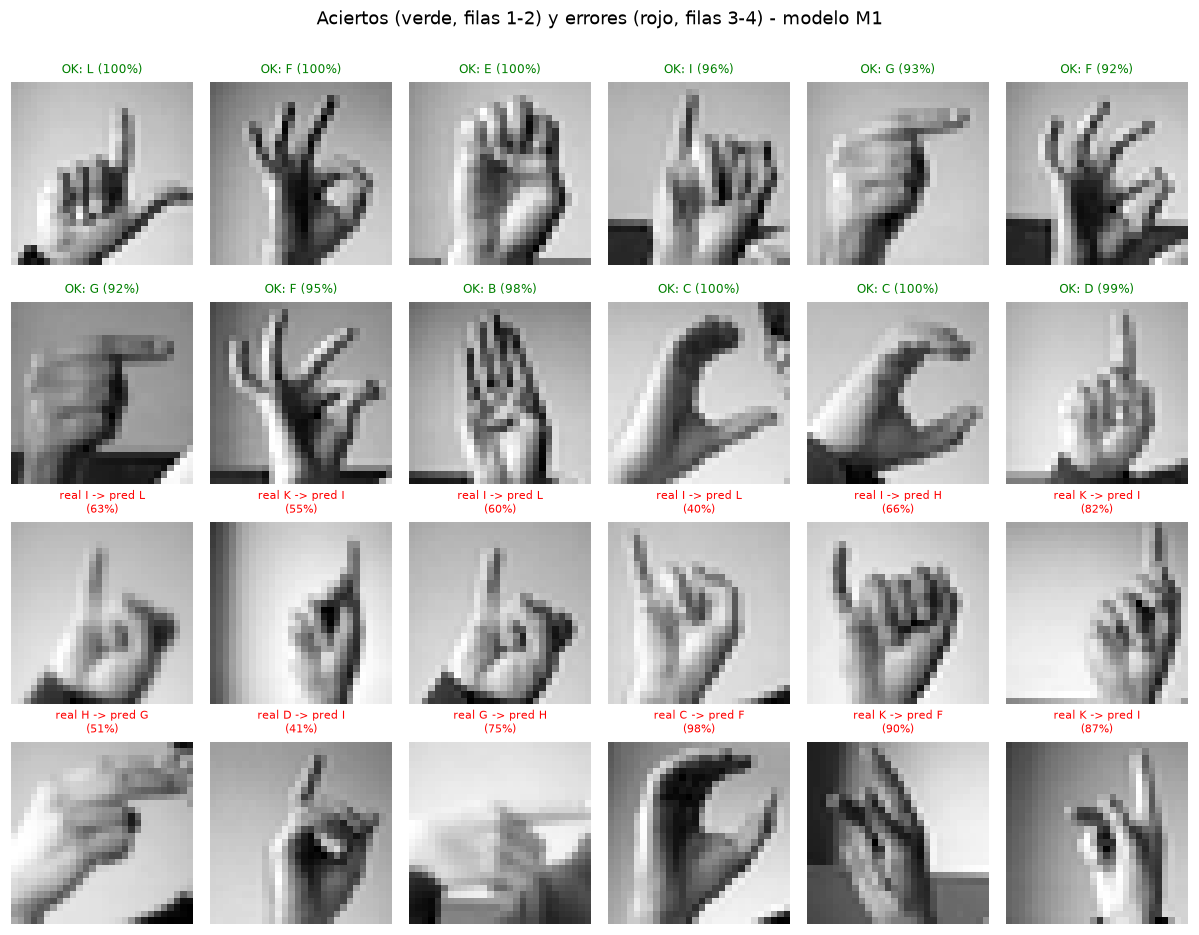

In [23]:
yp = res_m1["y_pred"]
mal = np.where(yp != y_test)[0]
bien = np.where(yp == y_test)[0]
prob = modelo_m1.predict_proba(X_test)
print(f"Aciertos: {len(bien)} de {len(y_test)} ({len(bien)/len(y_test)*100:.2f}%)")
print(f"Errores : {len(mal)}")

rng = np.random.default_rng(SEED)
sel_bien = rng.choice(bien, 12, replace=False)
sel_mal = rng.choice(mal, 12, replace=False)

fig, axes = plt.subplots(4, 6, figsize=(11, 8.6))
for c in range(6):
    for fila, i in enumerate([sel_bien[c], sel_bien[c+6]]):
        axes[fila, c].imshow(X_test[i].reshape(28, 28), cmap="gray"); axes[fila, c].axis("off")
        axes[fila, c].set_title(f"OK: {nombres_var[yp[i]]} ({prob[i, yp[i]]*100:.0f}%)",
                                fontsize=8, color="green")
    for fila, i in enumerate([sel_mal[c], sel_mal[c+6]], start=2):
        axes[fila, c].imshow(X_test[i].reshape(28, 28), cmap="gray"); axes[fila, c].axis("off")
        axes[fila, c].set_title(f"real {nombres_var[y_test[i]]} -> pred {nombres_var[yp[i]]}\n"
                                f"({prob[i, yp[i]]*100:.0f}%)", fontsize=7, color="red")
fig.text(0.5, 0.975, "Aciertos (verde, filas 1-2) y errores (rojo, filas 3-4) - modelo M1",
         ha="center", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.945]); plt.show()

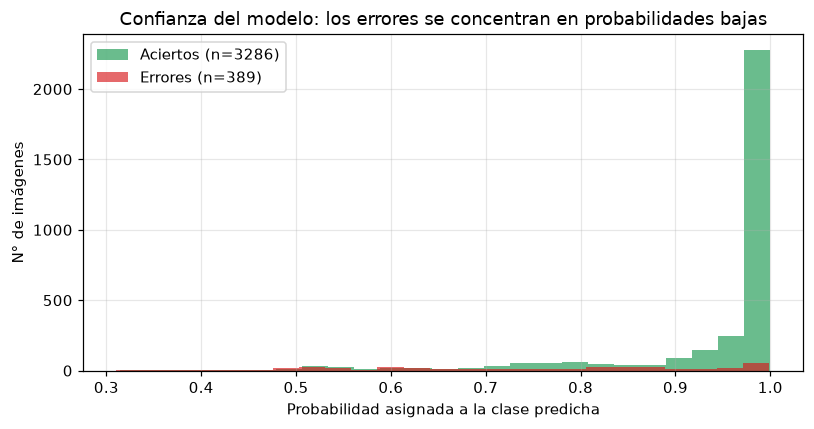

Confianza media en los aciertos: 0.942
Confianza media en los errores : 0.736


In [24]:
conf_ok = prob[bien][np.arange(len(bien)), yp[bien]]
conf_err = prob[mal][np.arange(len(mal)), yp[mal]]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(conf_ok, bins=25, alpha=.65, color="#1a9850", label=f"Aciertos (n={len(bien)})")
ax.hist(conf_err, bins=25, alpha=.65, color="#d7191c", label=f"Errores (n={len(mal)})")
ax.set_xlabel("Probabilidad asignada a la clase predicha"); ax.set_ylabel("N° de imágenes")
ax.set_title("Confianza del modelo: los errores se concentran en probabilidades bajas")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

print(f"Confianza media en los aciertos: {conf_ok.mean():.3f}")
print(f"Confianza media en los errores : {conf_err.mean():.3f}")

**Qué revela el gráfico de confianza.** Los aciertos se concentran cerca de probabilidad 1,0
(media ≈ 0,94), mientras que en los errores la probabilidad asignada es bastante menor
(media ≈ 0,74). La diferencia es sistemática: **la confianza de salida separa los aciertos de
los errores**. Esto es muy relevante en un sistema real, porque significa que la probabilidad
puede usarse como señal de abstención — cuando el modelo responde con confianza baja, conviene
pedirle al usuario que repita la seña en lugar de mostrar una letra potencialmente equivocada.
Un sistema de accesibilidad que se equivoca con confianza alta es peligroso; uno que "sabe que
no sabe" es utilizable.

Conviene ser precisos sobre el alcance de esta señal: la confianza **ordena** los casos bien y
mal clasificados, pero no los separa de forma perfecta — hay errores con confianza alta. Por
eso un umbral de abstención reduce los errores, pero no los elimina.

In [25]:
# Tabla de errores concretos con su segunda opción: ¿en qué se equivoca el modelo?
filas = []
for i in sel_mal:
    orden = np.argsort(prob[i])[::-1]
    filas.append({
        "letra_real": nombres_var[y_test[i]],
        "prediccion": nombres_var[orden[0]],
        "confianza_%": round(float(prob[i, orden[0]])*100, 1),
        "segunda_opcion": nombres_var[orden[1]],
        "confianza_2da_%": round(float(prob[i, orden[1]])*100, 1),
        "real_en_2da_pos": nombres_var[orden[1]] == nombres_var[y_test[i]],
    })
tabla_err = pd.DataFrame(filas)
print(tabla_err.to_string(index=False))
print()
print("Casos donde la letra correcta estuvo en el 2° lugar:", int(tabla_err["real_en_2da_pos"].sum()),
      "de", len(tabla_err))

letra_real prediccion  confianza_% segunda_opcion  confianza_2da_%  real_en_2da_pos
         I          L         62.6              I             21.0             True
         K          I         55.2              K             42.7             True
         I          L         59.6              B             11.0            False
         I          L         40.0              F             37.2            False
         I          H         65.9              I             26.5             True
         K          I         82.2              H             11.0            False
         H          G         51.1              H             48.9             True
         D          I         40.6              F             23.6            False
         G          H         75.5              G             23.9             True
         C          F         98.5              C              1.5             True
         K          F         89.6              K             10.4          

### Limitación fundamental: el MLP no entiende la geometría de una imagen

Esta es la discusión que la pauta pide explícitamente. Un **perceptrón multicapa es una red
de capas densas**: cada una de sus 784 entradas se conecta con cada neurona de la capa
siguiente, mediante un **peso propio y único**. Eso tiene tres consecuencias:

**1. No tiene invarianza a la traslación.** El peso que aprende para el píxel de la posición
(10, 14) no le sirve para el píxel (11, 14). Si la mano aparece dos píxeles más a la derecha,
la red ve una entrada distinta y no sabe que es la misma seña. Una CNN resuelve esto
**compartiendo los mismos pesos** (el mismo filtro) en toda la imagen, por lo que reconoce un
patrón sin importar dónde aparezca. Lo medimos empíricamente a continuación.

**2. Ignora la estructura espacial.** Al aplanar la imagen en un vector de 784 números, la
vecindad entre píxeles se pierde: el MLP no sabe que los píxeles 1 y 2 son vecinos y que el
píxel 29 está justo debajo del 1. Una CNN sí explota esa vecindad con sus convoluciones.

**3. Explosión de parámetros.** Una sola capa oculta de 128 neuronas sobre 784 entradas ya
tiene 100.480 pesos. Si las imágenes fueran de 256×256 (como en los datasets RGB propuestos
en el enunciado), la primera capa tendría 65.536 × 128 ≈ 8,4 millones de pesos — inmanejable
y garantía de sobreajuste. Las CNN reducen esto drásticamente al compartir pesos.

**4. Sensibilidad al fondo.** Como vimos en el EDA, más de la mitad de los píxeles son fondo
ruidoso, y el MLP les asigna pesos igual que a la mano.

Accuracy de M1 según el desplazamiento horizontal de la imagen:
  0 px (original)   : 0.8941   (cae un 0.0% respecto de 0 px)
  1 px              : 0.8659   (cae un 3.2% respecto de 0 px)
  2 px              : 0.6868   (cae un 23.2% respecto de 0 px)
  3 px              : 0.4337   (cae un 51.5% respecto de 0 px)


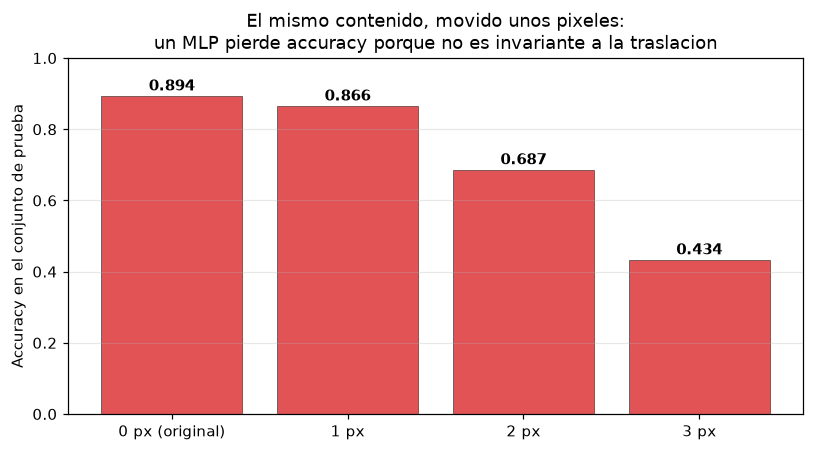

In [26]:
# Demostración cuantitativa: desplazamos el conjunto de prueba 1, 2 y 3 píxeles a la derecha.
# La seña es la MISMA (el desplazamiento no cambia la letra); solo cambia su posición.
resultados_traslacion = {"0 px (original)": res_m1["accuracy"]}
for k in (1, 2, 3):
    X_des = np.roll(X_test.reshape(-1, 28, 28), shift=k, axis=2).reshape(len(X_test), -1)
    resultados_traslacion[f"{k} px"] = accuracy_score(y_test, modelo_m1.predict(X_des))

print("Accuracy de M1 según el desplazamiento horizontal de la imagen:")
for k, v in resultados_traslacion.items():
    caida = (res_m1["accuracy"] - v) / res_m1["accuracy"] * 100
    print(f"  {k:18s}: {v:.4f}   (cae un {caida:.1f}% respecto de 0 px)")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(list(resultados_traslacion.keys()), list(resultados_traslacion.values()),
       color="#d7191c", alpha=.75, edgecolor="black", linewidth=.4)
for i, v in enumerate(resultados_traslacion.values()):
    ax.text(i, v + .015, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1); ax.set_ylabel("Accuracy en el conjunto de prueba")
ax.set_title("El mismo contenido, movido unos pixeles:\nun MLP pierde accuracy porque no es invariante a la traslacion")
ax.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

Aporte de informacion por region de la imagen (valores medios de la clase A):
  Centro (14x14): 196 de 196 pixeles con senal
  Borde         : 336 de 336 pixeles con senal

El borde no esta vacio: el fondo tambien aporta valores que la red aprende.


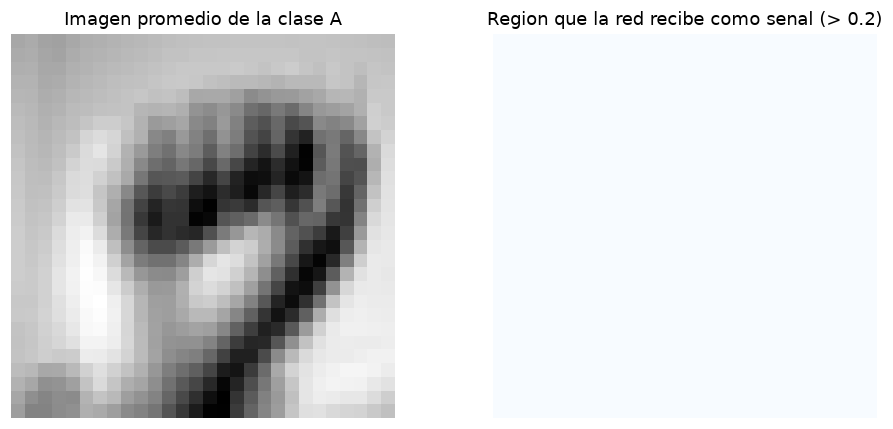

In [27]:
# ¿Y cómo se ve el ruido de fondo? El MLP aprende de los 784 píxeles, fondo incluido.
promedio_clase_A = X_train[y_train == 0].mean(axis=0).reshape(28, 28)
centro = promedio_clase_A[7:21, 7:21]
borde = np.concatenate([promedio_clase_A[:3].ravel(), promedio_clase_A[-3:].ravel(),
                        promedio_clase_A[:, :3].ravel(), promedio_clase_A[:, -3:].ravel()])

print("Aporte de informacion por region de la imagen (valores medios de la clase A):")
print(f"  Centro (14x14): {int((centro > 0.2).sum())} de {centro.size} pixeles con senal")
print(f"  Borde         : {int((borde  > 0.2).sum())} de {borde.size} pixeles con senal")
print()
print("El borde no esta vacio: el fondo tambien aporta valores que la red aprende.")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(promedio_clase_A, cmap="gray")
axes[0].set_title("Imagen promedio de la clase A")
axes[0].axis("off")
axes[1].imshow(promedio_clase_A > 0.2, cmap="Blues")
axes[1].set_title("Region que la red recibe como senal (> 0.2)")
axes[1].axis("off")
plt.tight_layout(); plt.show()

### ¿Por qué la validación interna es optimista? Evidencia

Comparamos la distribución de los píxeles entre el archivo de entrenamiento y el de prueba,
para descartar que la diferencia se deba a un problema de formato o a un cambio brusco de las
imágenes.

                               Train (27.455)  Test (7.172)
Intensidad media                       159.29        160.57
Desviación estándar                     48.77         49.04
Píxeles muy claros por imagen          152.19        163.70
Píxeles negros por imagen                1.59          1.38

Diferencia media entre las dos imágenes promedio: 2.01 niveles de gris


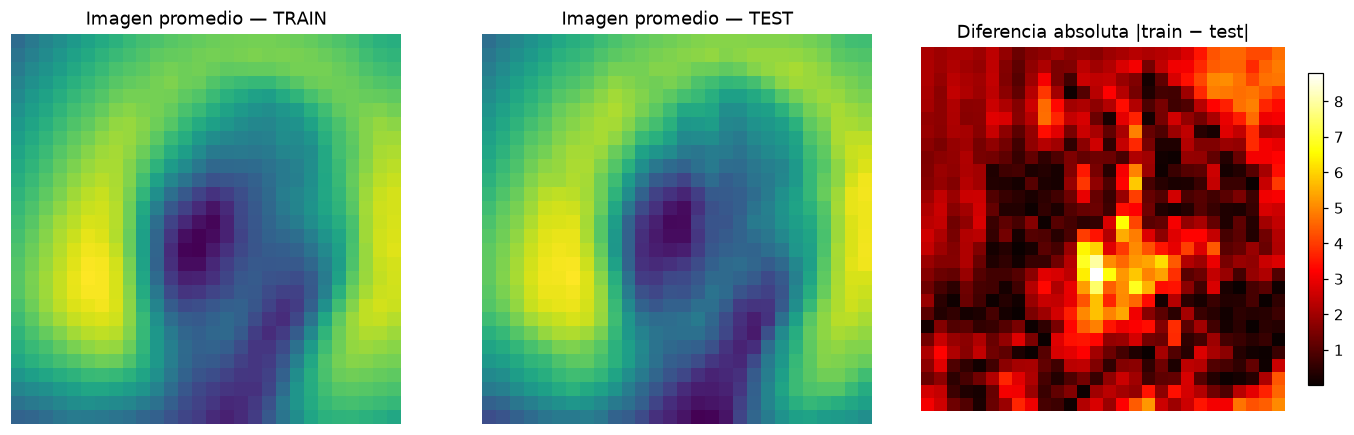

In [28]:
Xtr_raw = train_df.drop("label", axis=1).values.astype(np.float64)
Xte_raw = test_df.drop("label", axis=1).values.astype(np.float64)

comparacion = pd.DataFrame({
    "Train (27.455)": [Xtr_raw.mean(), Xtr_raw.std(),
                       (Xtr_raw > 200).sum(axis=1).mean(), (Xtr_raw == 0).sum(axis=1).mean()],
    "Test (7.172)": [Xte_raw.mean(), Xte_raw.std(),
                     (Xte_raw > 200).sum(axis=1).mean(), (Xte_raw == 0).sum(axis=1).mean()],
}, index=["Intensidad media", "Desviación estándar", "Píxeles muy claros por imagen",
          "Píxeles negros por imagen"]).round(2)
print(comparacion)
print()
print("Diferencia media entre las dos imágenes promedio:",
      round(float(np.abs(Xtr_raw.mean(axis=0) - Xte_raw.mean(axis=0)).mean()), 2), "niveles de gris")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(Xtr_raw.mean(axis=0).reshape(28, 28), cmap="viridis")
axes[0].set_title("Imagen promedio — TRAIN"); axes[0].axis("off")
axes[1].imshow(Xte_raw.mean(axis=0).reshape(28, 28), cmap="viridis")
axes[1].set_title("Imagen promedio — TEST"); axes[1].axis("off")
im = axes[2].imshow(np.abs(Xtr_raw.mean(axis=0) - Xte_raw.mean(axis=0)).reshape(28, 28), cmap="hot")
axes[2].set_title("Diferencia absoluta |train − test|"); axes[2].axis("off")
plt.colorbar(im, ax=axes[2], shrink=.8)
plt.tight_layout()
plt.savefig(os.path.join(IMG, "11_train_vs_test.png"), bbox_inches="tight")
plt.show()

**Conclusión de esta comparación.** Las dos particiones tienen estadísticas globales muy
similares (misma intensidad media, misma desviación estándar, mismo porcentaje de píxeles
claros). La diferencia **no** está en el formato ni en un cambio abrupto del brillo: está en
que provienen de **sesiones de captura distintas** de las mismas señas, con manos, escalas y
posiciones ligeramente diferentes dentro del cuadro.

Eso es exactamente el tipo de variación que un MLP no sabe ignorar: como vimos, unos pocos
píxeles de desplazamiento ya le cuestan una caída enorme de precisión. Por eso el desempeño
sobre el archivo de prueba es bastante menor que sobre la validación extraída del propio
archivo de entrenamiento. **No es un defecto del experimento: es la dificultad real del
problema**, y es la razón por la que el hold-out debe mantenerse intacto.

## h. Conclusiones

**Desempeño alcanzado.** El modelo M1 (11 letras, una capa oculta de 128 neuronas) alcanza un
**accuracy de aproximadamente 0,89** y un **F1 macro de aproximadamente 0,89** sobre el
conjunto de prueba, con precision y recall equilibrados entre sí. Para dimensionarlo: el
clasificador trivial que respondiera siempre la clase más frecuente acertaría solo el 9,1%
(1 de 11), así que el resultado evidencia aprendizaje real y no un sesgo del dataset.

Al mismo tiempo, medimos una **brecha de unos 10 puntos** entre el desempeño de entrenamiento
(prácticamente perfecto) y el de prueba. Reportamos ambos números juntos a propósito: presentar
solo el primero sería una medida engañosa del desempeño del sistema.

**Principales decisiones de diseño y su efecto:**

- **Normalización a [0,1]:** imprescindible para que Adam converja de forma estable.
- **Hold-out intacto:** permitió detectar la brecha de generalización que la validación interna
  ocultaba. Es la decisión metodológica más importante de todo el trabajo.
- **Arquitectura contenida (128 neuronas, L2, early stopping):** no impide el sobreajuste
  (el modelo memoriza el conjunto de entrenamiento), pero mantiene el modelo liviano y rápido
  de entrenar. La comparación M1 vs M2 muestra que agregar profundidad **no** compensa la
  ausencia de estructura espacial: sin convoluciones, más capas agregan parámetros y costo de
  cómputo sin resolver el problema de fondo.
- **Reformular el problema (11 letras en vez de 24) mejora el desempeño de forma notable**;
  el contraste con M3 cuantifica ese costo y demuestra que la dificultad crece más rápido que
  proporcionalmente: señales visualmente parecidas se vuelven indistinguibles para una red
  que no ve la geometría.

**Fortalezas del modelo:**

1. Métricas altas y parejas entre precision y recall (sin un sesgo marcado hacia alguna clase).
2. Reproducible: semilla fija, partición estratificada documentada, dependencias declaradas.
3. **Calibración útil:** los errores se concentran en confianzas bajas, lo que permite
   abstenerse en lugar de arriesgar una respuesta incorrecta.
4. Modelo liviano (se guarda en menos de 1 MB) y rápido de entrenar, adecuado para iterar.

**Limitaciones:**

1. **Ausencia de invarianza a la traslación y a la escala**, medida empíricamente en el
   experimento de desplazamiento.
2. **No explota la estructura espacial** de la imagen: la aplana antes de procesarla.
3. **Sensible al fondo y a la iluminación.** El dataset está "limpio"; una foto real de una
   webcam con fondo doméstico degradaría el desempeño, porque el modelo aprendió también el
   fondo sobre el que se tomaron las imágenes originales.
4. **Costo de parámetros:** no escala a imágenes de mayor resolución.
5. Solo reconoce **posturas estáticas**: no puede representar la J ni la Z, que requieren
   movimiento.

**Mejoras propuestas para futuras iteraciones:**

1. **Cambiar la arquitectura a una CNN**, que comparte pesos y por construcción es invariante
   a la traslación. Es el camino natural y corresponde a la Experiencia de Aprendizaje 2.
2. **Aumento de datos** (desplazamientos aleatorios, rotaciones leves, zoom) para enseñar al
   MLP, de forma forzada, la invarianza que no tiene por diseño.
3. **Extracción de características antes del MLP** (HOG, momentos de Hu o contornos), que
   entrega al clasificador descriptores invariantes en lugar de píxeles crudos.
4. **Segmentación previa** para eliminar el fondo y concentrar la red en la mano.
5. **Búsqueda sistemática de hiperparámetros** (número de capas, neuronas, tasa de
   aprendizaje) con validación cruzada, en lugar de la comparación puntual de esta entrega.
6. **Umbral de abstención** explícito, aprovechando que los errores se concentran en
   confianzas bajas.

**Reflexión final.** El valor de este trabajo no está en el número de accuracy alcanzado,
sino en haber aislado *por qué* un MLP es una herramienta limitada frente a imágenes y haber
demostrado esa limitación con evidencia experimental propia, no con una afirmación de manual.

## Reproducibilidad

| Elemento | Detalle |
|---|---|
| Semilla | `SEED = 42` (partición, inicialización de pesos, muestreo de ejemplos) |
| Partición | Entrenamiento 85% / Validación 15% del CSV `train`; CSV `test` como hold-out |
| Datos de entrada | `data/sign_mnist_train.csv` (27.455×785), `data/sign_mnist_test.csv` (7.172×785) |
| Dependencias | `requirements.txt` (numpy, pandas, scikit-learn, matplotlib) |
| Salidas | `models/*.joblib` (modelos entrenados), `models/metricas.json`, `images/*.png` |
| Ejecución | `jupyter notebook` → *Run All*, o `python scripts/02_modelo.py` |

### Estructura del proyecto

```
proyecto_tly1102/
├── README.md                  # Informe tecnico completo (CRISP-DM)
├── ENTREGA.md                 # Como entregar el trabajo (GitHub / campus)
├── requirements.txt           # Dependencias congeladas y verificadas
├── data/                      # sign_mnist_train.csv, sign_mnist_test.csv + alfabetos
├── notebooks/
│   └── EP1_TLY1102_MLP_SignLanguageMNIST.ipynb   # Este notebook
├── scripts/
│   ├── 01_eda.py              # Analisis exploratorio
│   ├── 02_modelo.py           # Pipeline de entrenamiento y evaluacion
│   ├── 03_demo_imagen.py      # Demo con imagen externa
│   ├── 07_exportar_ejemplos.py# Ejemplos del test para la demo
│   └── 08_verificar_demo.py   # Verifica que la demo sea fiel al dataset
├── models/                    # Modelos .joblib + metricas.json
├── images/                    # Todas las figuras generadas
├── presentacion/              # Diapositivas y guion de la defensa
└── references/                # Notas tecnicas
```

### Referencias

- Dataset: *Sign Language MNIST* (Kaggle) — 27.455 imágenes de entrenamiento y 7.172 de
  prueba, 784 píxeles en escala de grises, 24 clases (se excluyen J y Z por requerir movimiento).
- Documentación de `sklearn.neural_network.MLPClassifier`.
- Material de la asignatura TLY1102, Experiencia de Aprendizaje 1: *El Perceptrón*,
  *Redes Fully Connected*, *Descenso del Gradiente*, *Diseñando y evaluando el modelo*.